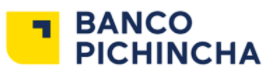






# Prueba práctica de conocimientos Data Engineer y Data Engineer Senior

### La prueba consta de 2 secciones:
### Sección 1: Temas de SQL:  Estos temas fueron elaborados en lenguaje SLQ Lite.
### Sección 2: Temas Pyspark.

##Preparación ambientes SQL y Pyspark

******************************************************************************************
###  En la siguiente sección encontrará un texto que dice " A LA IZQUIERDA DE ESTA LINEA ENCONTRARÁ EL BOTÓN PLAY".  Debe dar clic en ese botón para que pueda configurar el ambiente de compilación.
###  Despuesde dar play, verifique que el codigo se haya ejecutado en su totalidad viendo los mensajes "3.38.2" y "CONFIGURACION DE AMBIENTE SQL y SPARK FINALIZADO"
******************************************************************************************



In [1]:
############## A LA IZQUIERA DE ESTA LINEA ENCONTRÁ EL BOTON PLAY ##############
# Configurar ambiente Spark
print("INICIO CONFIGURACIÓN AMBIENTE SPARK")
!pip install pyspark
!pip install -U -q PyDrive
!apt install openjdk-8-jdk-headless -qq
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
#########################################
### Reinicio automatico ambiente
print("INICIO CONFIGURACIÓN AMBIENTE SQL")
!curl https://www.sqlite.org/src/tarball/sqlite.tar.gz?r=release | tar xz
%cd sqlite/
!./configure
!make sqlite3.c
%cd /content
!npx degit coleifer/pysqlite3 -f
!cp sqlite/sqlite3.[ch] .
!python setup.py build_static build
!cp build/lib.linux-x86_64-3.7/pysqlite3/_sqlite3.cpython-37m-x86_64-linux-gnu.so \
     /usr/lib/python3.7/lib-dynload/
#######################################
print("CONFIGURACION DE AMBIENTE SQL y SPARK FINALIZADO")

INICIO CONFIGURACIÓN AMBIENTE SPARK
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 15.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
The following additional packages will be installed:
  ca-certificates-java java-common libpcsclite1 libxtst6
  openjdk-8-jre-headless
Suggested packages:
  default-jre pcscd openjdk-8-demo openjdk-8-source libnss-mdns
  fonts-dejavu-extra fonts-nanum fonts-ipafont-gothic fonts-ipafont-mincho
  fonts-wqy-microhei fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  ca-certificates-java java-common libpcsclite1 libxtst6
  openjdk-8-jdk-headless openjdk-8-jre-headless
0 upgraded, 6 newly installed, 0 to remove and 41 not upgraded.
Need to get 39.7 MB of archives.
After this operation, 144 MB of additional disk space will be used.
Selecting previously unselected package java-common.
(Reading database ... 125080 files and directories currently installed.)
Preparing to unpack .../0-java-common_0.72build2_all.deb

###  Ejecutar la siguiente sección, reiniciara el ambiente y saldra un mensaje de fallo de la sesión, pero es originado por el reinicio necesario para que la configuración tenga efecto

In [ ]:
import os
os.kill(os.getpid(), 9)

### Ejecutar la siguiente sección. si todo  esta correctamente configurado el mensaje "3.38.2" debe aparecer

In [1]:
import sqlite3
print(sqlite3.sqlite_version)

3.37.2


# ----------------------------------------------------------------------------------------------------------

#Inicio prueba práctica

## Sección 1: SQL

###SQL: Antecedente -> Pregunta 1:

### Simulación de primera ronda Qatar 2022

Breve información de los datos disponibles:

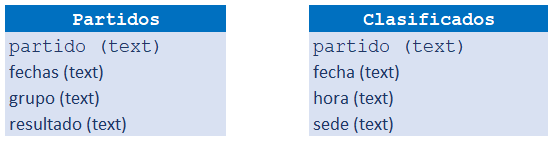

**Descripción:**

Se ha descargado de una página oficial dos sets de datos:

1.   Partidos.  Contiene información de la primera ronda de juegos a realizarse en el mundial de QATAR 2022 con una columna de resultado simulado por un algoritmo en etapa de pruebas.
2.   Clasificados. Contiene información de las fechas y sedes de la segunda ronda.  No se especifica los nombres de los equipos, únicamente una descripción de primer y segundo lugar dentro de cada grupo.
3.   Resultados_Qatar.  Es una tabla auxiliar que se utilizará en el ejercicio 2.  Esta tabla contiene los resultados esperados luego de ejecutar el script desarrollado por usted en el ejercicio 1.



NOTA:  
* Tener en cuenta que al ser data descargada de un portal, el origen no tiene las características de una base de datos relacional.

* Podría existir problemas de calidad de los datos que debe resolver en el query.

* Sus consultas se ejecutan utilizando SQLite, por lo que debe ajustarse a las construcciones SQL admitidas por SQLite.

####Para cargar el set de datos por favor ejecutar la siguiente celda:

In [2]:
## Delete the tables if they already exist

conn = sqlite3.connect('test.db')
print("Base de datos abierta con exito");

conn.execute('''drop table if exists Partidos;''')
conn.execute("create table Partidos(partido text, fechas text, grupo text, resultado text);")

conn.execute("insert into Partidos values('Qatar vs. Ecuador','21/11/2022','GRUPO A','0,1');")
conn.execute("insert into Partidos values('Senegal vs. Holanda','21/11/2022','GRUPO A','2,5');")
conn.execute("insert into Partidos values('Qatar vs. Senegal','25/11/2021','GRUPO A','0,5');")
conn.execute("insert into Partidos values('Holanda vs. Ecuador','25/11/2021','GRUPO A','3,3');")
conn.execute("insert into Partidos values('Holanda vs. Qatar','29/11/2021','GRUPO A','5,5');")
conn.execute("insert into Partidos values('Ecuador vs. Senegal','29/11/2021','GRUPO A','3,2');")
conn.execute("insert into Partidos values('Inglaterra vs. Irán','21/11/2022','GRUPO B','4,0');")
conn.execute("insert into Partidos values('Estados Unidos vs. Ucrania-Escocia-Gales','21/11/2022','GRUPO B','1,5');")
conn.execute("insert into Partidos values('Inglaterra vs. Estados Unidos','25/11/2021','GRUPO B','4,1');")
conn.execute("insert into Partidos values('Ucrania-Escocia-Gales vs. Iran','25/11/2021','GRUPO B','2,2');")
conn.execute("insert into Partidos values('Ucrania-Escocia-Gales vs. Inglaterra','29/11/2021','GRUPO B','0,1');")
conn.execute("insert into Partidos values('Irán vs. Estados Unidos','29/11/2021','GRUPO B','0,0');")
conn.execute("insert into Partidos values('Argentina vs. Arabia Saudi','22/11/2022','GRUPO C','5,1');")
conn.execute("insert into Partidos values('México vs. Polonia','22/11/2022','GRUPO C','1,5');")
conn.execute("insert into Partidos values('Argentina vs. México','26/11/2021','GRUPO C','3,0');")
conn.execute("insert into Partidos values('Polonia vs. Arabia Saudí','26/11/2021','GRUPO C','1,2');")
conn.execute("insert into Partidos values('Polonia vs. Argentina','30/11/2021','GRUPO C','2,4');")
conn.execute("insert into Partidos values('Arabia Saudí vs. México','30/11/2021','GRUPO C','5,5');")
conn.execute("insert into Partidos values('Francia vs. Peru-Australia-EAU','22/11/2022','GRUPO D','1,1');")
conn.execute("insert into Partidos values('Dinamarca vs. Túnez','22/11/2022','GRUPO D','5,2');")
conn.execute("insert into Partidos values('Francia vs. Dinamarca','26/11/2021','GRUPO D','0,0');")
conn.execute("insert into Partidos values('Túnez vs. Perú-Australia-EAU','26/11/2021','GRUPO D','0,5');")
conn.execute("insert into Partidos values('Túnez vs. Francia','30/11/2021','GRUPO D','4,0');")
conn.execute("insert into Partidos values('Perú-Australia-EAU vs. Dinamarca','30/11/2021','GRUPO D','0,0');")
conn.execute("insert into Partidos values('España vs. Costa Rica-Nueva Zelanda.','23/11/2022','GRUPO E','2,0');")
conn.execute("insert into Partidos values('Alemania vs. Japón','23/11/2022','GRUPO E','5,3');")
conn.execute("insert into Partidos values('España vs. Alemania','27/11/2021','GRUPO E','1,2');")
conn.execute("insert into Partidos values('Japón vs. Costa Rica-Nueva Zelanda','27/11/2021','GRUPO E','2,2');")
conn.execute("insert into Partidos values('Japón vs. Espana','01/12/2021','GRUPO E','2,1');")
conn.execute("insert into Partidos values('Costa Rica-Nueva Zelanda vs. Alemania','01/12/2021','GRUPO E','3,0');")
conn.execute("insert into Partidos values('Portugal vs. Ghana','24/11/2022','GRUPO F','2,1');")
conn.execute("insert into Partidos values('Uruguay vs. Corea del Sur','24/11/2022','GRUPO F','0,2');")
conn.execute("insert into Partidos values('Portugal vs. Uruguay','28/11/2021','GRUPO F','1,1');")
conn.execute("insert into Partidos values('Corea del Sur vs. Ghana','28/11/2021','GRUPO F','3,1');")
conn.execute("insert into Partidos values('Corea del Sur vs. Portugal.','02/12/2021','GRUPO F','4,5');")
conn.execute("insert into Partidos values('Ghana vs. Uruguay.','02/12/2021','GRUPO F','2,3');")

# Localidades y fecha de los partidos de la segunda ronda

conn.execute('''drop table if exists Clasificados;''')
conn.execute("create table Clasificados(partido text, fecha text, hora text, sede text);")

conn.execute("insert into Clasificados values('1º del grupo A vs. 2º del grupo B','03/12/2022','06:00:00 PM','Estadio Khalifa, Rayán');")
conn.execute("insert into Clasificados values('1º del grupo C vs. 2º del grupo D','03/12/2022','10:00:00 PM','Estadio Ahmed bin Ali, Rayán');")
conn.execute("insert into Clasificados values('1º del grupo D vs. 2º del grupo C','04/12/2022','06:00:00 PM','Estadio Al Thumama, Doha');")
conn.execute("insert into Clasificados values('1º del grupo B vs. 2º del grupo A','04/12/2022','10:00:00 PM','Estadio Al Bayt, Jor');")
conn.execute("insert into Clasificados values('1º del grupo E vs. 2º del grupo F','05/12/2022','06:00:00 PM','Estadio Al Janoub, Al Wakrah');")
conn.execute("insert into Clasificados values('1º del grupo G vs. 2º del grupo H','05/12/2022','10:00:00 PM','Estadio 974, Doha');")
conn.execute("insert into Clasificados values('1º del grupo F vs. 2º del grupo E','06/12/2022','06:00:00 PM','Estadio Qatar Foundation, Rayán');")
conn.execute("insert into Clasificados values('1º del grupo H vs. 2º del grupo G','06/12/2022','10:00:00 PM','Estadio Icónico, Lusail');")

# Totales obtenidos de la simulación por equipo

conn.execute('''drop table if exists Resultados_Qatar;''')
conn.execute("create table Resultados_Qatar(equipo text,grupo text, puntos int, gol_diferencia int);")

conn.execute("insert into Resultados_Qatar values('ALEMANIA','GRUPO E','6','0');")
conn.execute("insert into Resultados_Qatar values('ARABIA SAUDI','GRUPO C','4','-3');")
conn.execute("insert into Resultados_Qatar values('ARGENTINA','GRUPO C','9','9');")
conn.execute("insert into Resultados_Qatar values('COREA DEL SUR','GRUPO F','6','3');")
conn.execute("insert into Resultados_Qatar values('COSTA RICA-NUEVA ZELANDA','GRUPO E','4','1');")
conn.execute("insert into Resultados_Qatar values('DINAMARCA','GRUPO D','5','3');")
conn.execute("insert into Resultados_Qatar values('ECUADOR','GRUPO A','7','2');")
conn.execute("insert into Resultados_Qatar values('ESPANA','GRUPO E','3','0');")
conn.execute("insert into Resultados_Qatar values('ESTADOS UNIDOS','GRUPO B','1','-7');")
conn.execute("insert into Resultados_Qatar values('FRANCIA','GRUPO D','2','-4');")
conn.execute("insert into Resultados_Qatar values('GHANA','GRUPO F','0','-4');")
conn.execute("insert into Resultados_Qatar values('HOLANDA','GRUPO A','5','3');")
conn.execute("insert into Resultados_Qatar values('INGLATERRA','GRUPO B','9','8');")
conn.execute("insert into Resultados_Qatar values('IRAN','GRUPO B','2','-4');")
conn.execute("insert into Resultados_Qatar values('JAPON','GRUPO E','4','-1');")
conn.execute("insert into Resultados_Qatar values('MEXICO','GRUPO C','1','-7');")
conn.execute("insert into Resultados_Qatar values('PERU-AUSTRALIA-EAU','GRUPO D','5','5');")
conn.execute("insert into Resultados_Qatar values('POLONIA','GRUPO C','3','1');")
conn.execute("insert into Resultados_Qatar values('PORTUGAL','GRUPO F','7','2');")
conn.execute("insert into Resultados_Qatar values('QATAR','GRUPO A','1','-6');")
conn.execute("insert into Resultados_Qatar values('SENEGAL','GRUPO A','3','1');")
conn.execute("insert into Resultados_Qatar values('TUNEZ','GRUPO D','3','-4');")
conn.execute("insert into Resultados_Qatar values('UCRANIA-ESCOCIA-GALES','GRUPO B','4','3');")
conn.execute("insert into Resultados_Qatar values('URUGUAY','GRUPO F','4','-1');")

conn.commit()
print("Valores insertados con éxito");




Base de datos abierta con exito
Valores insertados con éxito


####SQL: Pregunta 1:  Se ha realizado una simulación de la primera ronda de partidos en el mundial de QATAR 2022, cuyos resultados se han almacenado en la tabla "Partidos".  Mediante un proceso manual en Excel se elaboró el siguiente resumen: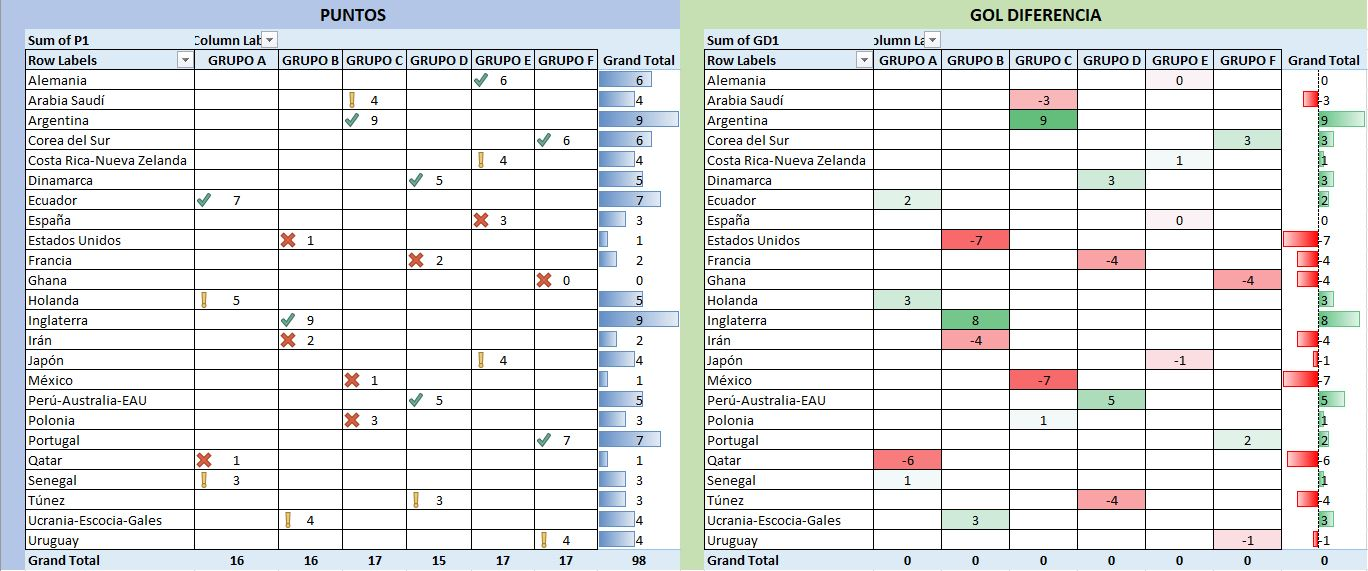

<b>PEDIDO:  Se solicita elaborar un reporte que calcule de forma automática la siguiente información:  Equipo, Grupo al que pertenece, Total Puntos Obtenidos en todos los partidos y Sumatoria del Gol Diferencia logrado en cada partido.

--------------------------------------------
<b>Reglas para asignación de Puntos:
--------------------------------------------
  * Si gana un partido obtendrá 3 puntos.
  * Si pierde un partido obtendrá 0 puntos.
  * Si empata un partido obtendrá 1 punto.
----------------------------------------------------------------
<b>Gol Diferencia:
----------------------------------------------------------------
  * Sumatoria del total de número de goles anotados menos número de goles recibidos.

-------------------------------------------
Fuente:  Tabla "Partidos"

In [3]:
import pandas as pd

#Ejercicio #1
#conexión a la bdd
conn = sqlite3.connect('test.db')

#leer el contenido de la tabla partidos
df = pd.read_sql_query("SELECT * FROM Partidos;", conn)

#dimensiones del ds
print('\nDIMENSIONES DE LA TABLA PARTIDOS')
print(df.shape)

print('\nDATOS DE LA TABLA PARTIDOS')

#mostrar la tabla
display(df)

print('\nVERIFICACIÓN DE DATOS (PARTIDOS Y RESULTADOS) PARA EL EJERCICIO')

#verificación de que la columna de resultados todas dispongan el valor con el formato correcto separados por una ,
df_resultados_err = pd.read_sql_query("""
SELECT * FROM Partidos
WHERE resultado NOT LIKE '%,%';
""", conn)

#verificación de que la columna partido disponga del valor con el formato correcto es decir separado por vs. para identificar a los equipos
df_partidos_err = pd.read_sql_query("""
SELECT * FROM Partidos
WHERE lower(partido) NOT LIKE '%vs%';
""", conn)

#resultado de las verfiicaciones
print("\nFilas con resultado mal formado (sin coma):")
display(df_resultados_err)

print("\nFilas con partido mal formado (sin 'vs'):")
display(df_partidos_err)


#cerrar la conexión
conn.close()


DIMENSIONES DE LA TABLA PARTIDOS
(36, 4)

DATOS DE LA TABLA PARTIDOS


,partido,fechas,grupo,resultado
0,Qatar vs. Ecuador,21/11/2022,GRUPO A,"0,1"
1,Senegal vs. Holanda,21/11/2022,GRUPO A,"2,5"
2,Qatar vs. Senegal,25/11/2021,GRUPO A,"0,5"
3,Holanda vs. Ecuador,25/11/2021,GRUPO A,"3,3"
4,Holanda vs. Qatar,29/11/2021,GRUPO A,"5,5"
5,Ecuador vs. Senegal,29/11/2021,GRUPO A,"3,2"
6,Inglaterra vs. Irán,21/11/2022,GRUPO B,"4,0"
7,Estados Unidos vs. Ucrania-Escocia-Gales,21/11/2022,GRUPO B,"1,5"
8,Inglaterra vs. Estados Unidos,25/11/2021,GRUPO B,"4,1"
9,Ucrania-Escocia-Gales vs. Iran,25/11/2021,GRUPO B,"2,2"



VERIFICACIÓN DE DATOS (PARTIDOS Y RESULTADOS) PARA EL EJERCICIO

Filas con resultado mal formado (sin coma):


,partido,fechas,grupo,resultado



Filas con partido mal formado (sin 'vs'):


,partido,fechas,grupo,resultado


Se determina que tanto los partidos como los resultados tienen el formato correcto para el proceso.

In [4]:
##vamos a revisar si los nombres de los equipos son únicos
conn = sqlite3.connect('test.db')

cursor = conn.execute('''
SELECT DISTINCT equipo
FROM (
    SELECT TRIM(SUBSTR(partido, 1, INSTR(LOWER(partido), 'vs.') - 1)) AS equipo
    FROM Partidos
    UNION
    SELECT TRIM(SUBSTR(partido, INSTR(LOWER(partido), 'vs.') + 3)) AS equipo
    FROM Partidos
)
ORDER BY equipo;
''')

print('\nVERIFICACIÓN DE DATOS (EQUIPOS) PARA EL EJERCICIO')
print('\n')

for row in cursor:
    print(row[0])

conn.close()


VERIFICACIÓN DE DATOS (EQUIPOS) PARA EL EJERCICIO


Alemania
Arabia Saudi
Arabia Saudí
Argentina
Corea del Sur
Costa Rica-Nueva Zelanda
Costa Rica-Nueva Zelanda.
Dinamarca
Ecuador
Espana
España
Estados Unidos
Francia
Ghana
Holanda
Inglaterra
Iran
Irán
Japón
México
Peru-Australia-EAU
Perú-Australia-EAU
Polonia
Portugal
Portugal.
Qatar
Senegal
Túnez
Ucrania-Escocia-Gales
Uruguay
Uruguay.


Como se puede visualizar existen algunos países que están duplicados debido a faltas de ortografía o caracteres extra por lo que se los va a actualizar en la tabla previo al análisis:

In [5]:
conn = sqlite3.connect('test.db')
cursor = conn.cursor()

# Lista de reemplazos (viejo, nuevo)
reemplazos = [
    ('Peru-Australia-EAU', 'Perú-Australia-EAU'),
    ('Costa Rica-Nueva Zelanda.', 'Costa Rica-Nueva Zelanda'),
    ('Espana', 'España'),
    ('Portugal.', 'Portugal'),
    ('Uruguay.', 'Uruguay'),
    ('Arabia Saudi', 'Arabia Saudí'),
     ('Iran', 'Irán')
]

# Aplicar los reemplazos directamente en el campo 'partido'
for viejo, nuevo in reemplazos:
    cursor.execute("UPDATE Partidos SET partido = REPLACE(partido, ?, ?)", (viejo, nuevo))

conn.commit()

cursor = conn.execute('''
SELECT DISTINCT equipo
FROM (
    SELECT TRIM(SUBSTR(partido, 1, INSTR(LOWER(partido), 'vs.') - 1)) AS equipo
    FROM Partidos
    UNION
    SELECT TRIM(SUBSTR(partido, INSTR(LOWER(partido), 'vs.') + 3)) AS equipo
    FROM Partidos
)
ORDER BY equipo;
''')

print('\nEQUIPOS DESPUÉS DE LA ACTUALIZACIÓN')
print('\n')

for row in cursor:
    print(row[0])

conn.close()


EQUIPOS DESPUÉS DE LA ACTUALIZACIÓN


Alemania
Arabia Saudí
Argentina
Corea del Sur
Costa Rica-Nueva Zelanda
Dinamarca
Ecuador
España
Estados Unidos
Francia
Ghana
Holanda
Inglaterra
Irán
Japón
México
Perú-Australia-EAU
Polonia
Portugal
Qatar
Senegal
Túnez
Ucrania-Escocia-Gales
Uruguay


In [6]:
conn = sqlite3.connect('test.db')

###CURSOR PREVIO PARA HACER LA SEPARACIÓN DE DATOS, AL CÁLCULO Y DESPLIEGUE FINAL
print('\nDESGLOSE DE INFORMACIÓN PREVIO AL PROCESAMIENTO: \ngrupo, equipo_local, equipo_visitante, goles_local,goles_visitante, fechas, puntos_local, puntos_visitante, gol_dif_local, gol_dif_visitante')
print('\n')
cursor = conn.execute('''
                      SELECT grupo,
                            TRIM(SUBSTR(partido, 1, INSTR(LOWER(partido), 'vs.') - 1)) AS equipo_local,
                            TRIM(SUBSTR(partido, INSTR(LOWER(partido), 'vs.') + 3)) AS equipo_visitante,
                            CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) AS goles_local,
                            CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) AS goles_visitante,
                            fechas,
                            CASE
                                WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) > CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER)
                                    THEN 3
                                WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) = CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER)
                                    THEN 1
                                ELSE 0
                            END AS puntos_local,
                            CASE
                                WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) < CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER)
                                    THEN 3
                                WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) = CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER)
                                    THEN 1
                                ELSE 0
                            END AS puntos_visitante,
                            CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) - CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) AS gol_dif_local,
                            CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) - CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) AS gol_dif_visitante
                      FROM Partidos
                      ORDER BY grupo;

                       ''')

for row in cursor:
  print(row)
conn.close()


DESGLOSE DE INFORMACIÓN PREVIO AL PROCESAMIENTO: 
grupo, equipo_local, equipo_visitante, goles_local,goles_visitante, fechas, puntos_local, puntos_visitante, gol_dif_local, gol_dif_visitante


('GRUPO A', 'Qatar', 'Ecuador', 0, 1, '21/11/2022', 0, 3, -1, 1)
('GRUPO A', 'Senegal', 'Holanda', 2, 5, '21/11/2022', 0, 3, -3, 3)
('GRUPO A', 'Qatar', 'Senegal', 0, 5, '25/11/2021', 0, 3, -5, 5)
('GRUPO A', 'Holanda', 'Ecuador', 3, 3, '25/11/2021', 1, 1, 0, 0)
('GRUPO A', 'Holanda', 'Qatar', 5, 5, '29/11/2021', 1, 1, 0, 0)
('GRUPO A', 'Ecuador', 'Senegal', 3, 2, '29/11/2021', 3, 0, 1, -1)
('GRUPO B', 'Inglaterra', 'Irán', 4, 0, '21/11/2022', 3, 0, 4, -4)
('GRUPO B', 'Estados Unidos', 'Ucrania-Escocia-Gales', 1, 5, '21/11/2022', 0, 3, -4, 4)
('GRUPO B', 'Inglaterra', 'Estados Unidos', 4, 1, '25/11/2021', 3, 0, 3, -3)
('GRUPO B', 'Ucrania-Escocia-Gales', 'Irán', 2, 2, '25/11/2021', 1, 1, 0, 0)
('GRUPO B', 'Ucrania-Escocia-Gales', 'Inglaterra', 0, 1, '29/11/2021', 0, 3, -1, 1)
('GRUPO B', 'Irán',

In [7]:
# Ejercicio # 1
conn = sqlite3.connect('test.db')

####PROGRAME SU RESPUESTA DENTRO DEL CONN.EXECUTE ENTRE LAS COMILLAS
print('\nREPORTE SOLICITADO: \ngrupo, equipo, total_puntos, total_gol_diferencia')
print('\n')

cursor = conn.execute('''
--voy a tomar cada partido y voy a separarlo una línea por local y otra por visitante para así tener el resultado por equipo en una sola línea
SELECT
    grupo,
    equipo,
    SUM(puntos) AS total_puntos,
    SUM(gol_diferencia) AS total_gol_diferencia
FROM(
    --consulta para extraer los partidos como local
    SELECT TRIM(SUBSTR(partido, 1, INSTR(lower(partido), 'vs.') - 1)) AS equipo,
    grupo,
    CASE
        WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) >
             CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) THEN 3
        WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) =
                 CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) THEN 1
        ELSE 0
    END AS puntos,
    CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) -
        CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) AS gol_diferencia
    FROM Partidos
    UNION ALL
    --consulta para extraer los partidos como visitante
    SELECT TRIM(SUBSTR(partido, INSTR(lower(partido), 'vs.') + 3)) AS equipo,
    grupo,
    CASE
        WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) <
                 CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) THEN 3
        WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) =
                 CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) THEN 1
        ELSE 0
    END AS puntos,
    CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) - CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) AS gol_diferencia
    FROM Partidos
)
group by grupo, equipo
order by grupo, equipo, total_puntos;

                       ''')
for row in cursor:
  print(row)

conn.close()



REPORTE SOLICITADO: 
grupo, equipo, total_puntos, total_gol_diferencia


('GRUPO A', 'Ecuador', 7, 2)
('GRUPO A', 'Holanda', 5, 3)
('GRUPO A', 'Qatar', 1, -6)
('GRUPO A', 'Senegal', 3, 1)
('GRUPO B', 'Estados Unidos', 1, -7)
('GRUPO B', 'Inglaterra', 9, 8)
('GRUPO B', 'Irán', 2, -4)
('GRUPO B', 'Ucrania-Escocia-Gales', 4, 3)
('GRUPO C', 'Arabia Saudí', 4, -3)
('GRUPO C', 'Argentina', 9, 9)
('GRUPO C', 'México', 1, -7)
('GRUPO C', 'Polonia', 3, 1)
('GRUPO D', 'Dinamarca', 5, 3)
('GRUPO D', 'Francia', 2, -4)
('GRUPO D', 'Perú-Australia-EAU', 5, 5)
('GRUPO D', 'Túnez', 3, -4)
('GRUPO E', 'Alemania', 6, 0)
('GRUPO E', 'Costa Rica-Nueva Zelanda', 4, 1)
('GRUPO E', 'España', 3, 0)
('GRUPO E', 'Japón', 4, -1)
('GRUPO F', 'Corea del Sur', 6, 3)
('GRUPO F', 'Ghana', 0, -4)
('GRUPO F', 'Portugal', 7, 2)
('GRUPO F', 'Uruguay', 4, -1)


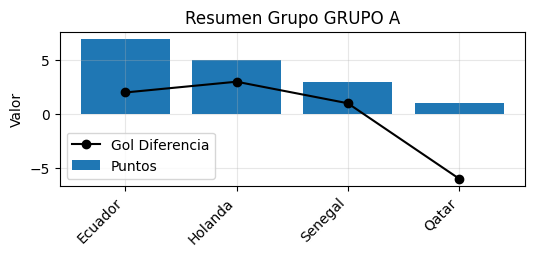

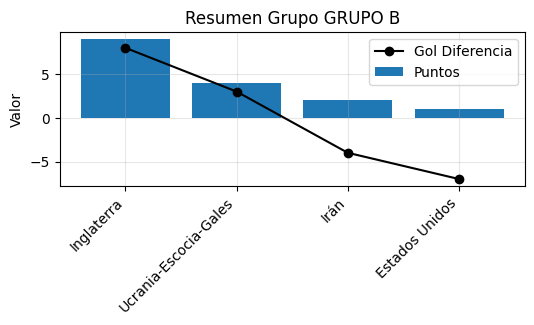

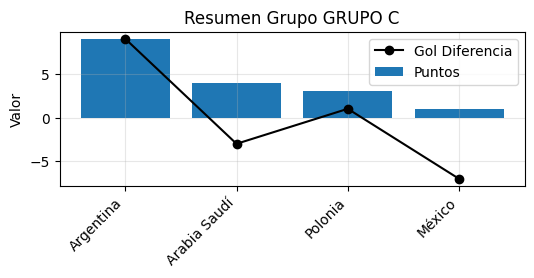

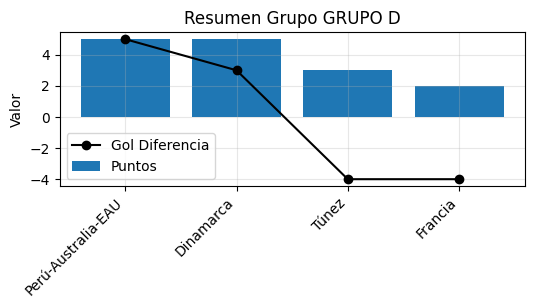

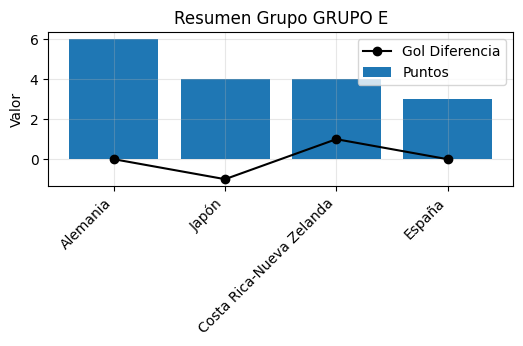

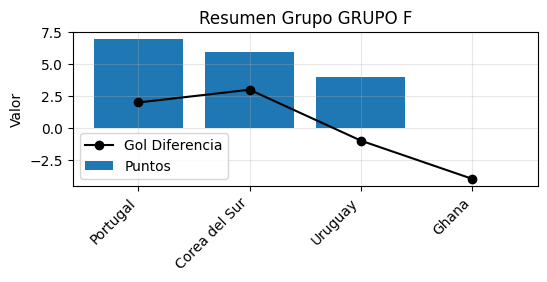

In [8]:
import matplotlib.pyplot as plt

conn = sqlite3.connect('test.db')

#genero un dataset con el query que se desplegó el reporte para por
query = '''
SELECT
    grupo,
    equipo,
    SUM(puntos) AS total_puntos,
    SUM(gol_dif) AS total_gol_diferencia
FROM (
    SELECT
        TRIM(SUBSTR(partido, 1, INSTR(LOWER(partido), 'vs.') - 1)) AS equipo,
        grupo,
        CASE
            WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) >
                 CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) THEN 3
            WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) =
                 CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) THEN 1
            ELSE 0
        END AS puntos,
        CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) -
        CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) AS gol_dif
    FROM Partidos
    UNION ALL
    SELECT
        TRIM(SUBSTR(partido, INSTR(LOWER(partido), 'vs.') + 3)) AS equipo,
        grupo,
        CASE
            WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) <
                 CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) THEN 3
            WHEN CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) =
                 CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) THEN 1
            ELSE 0
        END AS puntos,
        CAST(SUBSTR(resultado, INSTR(resultado, ',') + 1) AS INTEGER) -
        CAST(SUBSTR(resultado, 1, INSTR(resultado, ',') - 1) AS INTEGER) AS gol_dif
    FROM Partidos
)
GROUP BY grupo, equipo
ORDER BY grupo, total_puntos DESC;
'''

df = pd.read_sql_query(query, conn)
conn.close()

# Gráficos por grupo
grupos = df['grupo'].unique()

for grupo in grupos:
    data = df[df['grupo'] == grupo]
    plt.figure(figsize=(6,2))
    plt.bar(data['equipo'], data['total_puntos'], label='Puntos')
    plt.plot(data['equipo'], data['total_gol_diferencia'], 'o-', color='black', label='Gol Diferencia')
    plt.title(f'Resumen Grupo {grupo}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

####SQL: Pregunta 2: Hemos cargado una tabla auxiliar con los resultados esperados de la Pregunta 1. La tabla se llama: "Resultados_Qatar" y tiene la siguiente estructura: (equipo, GRUPO, puntos, gol_diferencia)

<b>PEDIDOS:


2.1.   Determinar los 2 equipos con mayor puntaje que pasarán a la siguiente ronda por cada grupo.  En caso de que existan mas de dos equipos con derecho a pasar por tener igual número de puntos, se definirá quien pasa considerando el que tenga el mayor gol diferencia.

2.2.   Agregar un campo indicando en qué ciudad y Fecha/hora que jugarán en la siguiente ronda los equipos clasificados.

------------------------------------------------------
FUENTES:  


*   Tabla "Resultados_Qatar" que contiene los resultados por equipo.
*   Tabla "Clasificados" para concer las localidades

In [9]:
# Ejercicio # 2
conn = sqlite3.connect('test.db')

####PROGRAME SU RESPUESTA DENTRO DEL CONN.EXECUTE ENTRE LAS COMILLAS

#primero vamos a determinar los 2 equipos con mayor puntaje de cada grupo
#o con igual puntaje según el gol diferencia según sea el caso según la regla
cursor = conn.execute('''
                        SELECT grupo, equipo, puntos, gol_diferencia
                        FROM (
                              SELECT grupo, equipo, puntos, gol_diferencia,
                                    ROW_NUMBER() OVER (
                                        PARTITION BY grupo
                                        ORDER BY puntos DESC, gol_diferencia DESC
                                    ) AS posicion
                              FROM Resultados_Qatar
                          )
                          WHERE posicion <= 2
                          ORDER BY grupo, posicion;
                       ''')

print('\nEQUIPOS CLASIFICADOS POR GRUPO')
print('\n')

for row in cursor:
  print(row)

#para hacer la visualización de los siguientes partidos de la segunda fase de grupos voy a generar una nueva tabla para tener de manera más
#ordenada la información

cursor.execute('DROP TABLE IF EXISTS Partidos_Segunda_Ronda;')

cursor.execute('''
      CREATE TABLE Partidos_Segunda_Ronda (
          equipo_local TEXT,
          equipo_visitante TEXT,
          fecha TEXT,
          hora TEXT,
          sede TEXT
      );
''')

# se inserta en la tabla creada los partidos cruzando los 1º y 2º de cada grupo con la tabla Clasificados
cursor.execute('''
      WITH Clasificados_Puestos AS (
          SELECT grupo, equipo,
                ROW_NUMBER() OVER (PARTITION BY grupo ORDER BY puntos DESC, gol_diferencia DESC) AS posicion
          FROM Resultados_Qatar
      ),
      Primeros AS (
          SELECT grupo, equipo FROM Clasificados_Puestos WHERE posicion = 1
      ),
      Segundos AS (
          SELECT grupo, equipo FROM Clasificados_Puestos WHERE posicion = 2
      )
      INSERT INTO Partidos_Segunda_Ronda (equipo_local, equipo_visitante, fecha, hora, sede)
      SELECT
          p1.equipo AS equipo_local,
          s2.equipo AS equipo_visitante,
          c.fecha,
          c.hora,
          c.sede
      FROM Clasificados c
      JOIN Primeros p1 ON instr(c.partido, '1º del grupo ' || SUBSTR(p1.grupo, -1)) > 0
      JOIN Segundos s2 ON instr(c.partido, '2º del grupo ' || SUBSTR(s2.grupo, -1)) > 0
      ORDER BY c.fecha, c.hora;
''')

conn.commit()

# mostramos el orden de los partidos en la segunda ronda
cursor.execute('SELECT * FROM Clasificados;')

print('\nORDEN DE LOS PARTIDOS DE LOS CLASIFICADOS')
print('\n')

for row in cursor:
    print(row)

# mostramos los resultados
cursor.execute('SELECT * FROM Partidos_Segunda_Ronda;')

print('\nPARTIDOS DE LA SEGUNDA RONDA')
print('\n')

for row in cursor:
    print(row)

conn.close()



EQUIPOS CLASIFICADOS POR GRUPO


('GRUPO A', 'ECUADOR', 7, 2)
('GRUPO A', 'HOLANDA', 5, 3)
('GRUPO B', 'INGLATERRA', 9, 8)
('GRUPO B', 'UCRANIA-ESCOCIA-GALES', 4, 3)
('GRUPO C', 'ARGENTINA', 9, 9)
('GRUPO C', 'ARABIA SAUDI', 4, -3)
('GRUPO D', 'PERU-AUSTRALIA-EAU', 5, 5)
('GRUPO D', 'DINAMARCA', 5, 3)
('GRUPO E', 'ALEMANIA', 6, 0)
('GRUPO E', 'COSTA RICA-NUEVA ZELANDA', 4, 1)
('GRUPO F', 'PORTUGAL', 7, 2)
('GRUPO F', 'COREA DEL SUR', 6, 3)

ORDEN DE LOS PARTIDOS DE LOS CLASIFICADOS


('1º del grupo A vs. 2º del grupo B', '03/12/2022', '06:00:00 PM', 'Estadio Khalifa, Rayán')
('1º del grupo C vs. 2º del grupo D', '03/12/2022', '10:00:00 PM', 'Estadio Ahmed bin Ali, Rayán')
('1º del grupo D vs. 2º del grupo C', '04/12/2022', '06:00:00 PM', 'Estadio Al Thumama, Doha')
('1º del grupo B vs. 2º del grupo A', '04/12/2022', '10:00:00 PM', 'Estadio Al Bayt, Jor')
('1º del grupo E vs. 2º del grupo F', '05/12/2022', '06:00:00 PM', 'Estadio Al Janoub, Al Wakrah')
('1º del grupo G vs. 2º del grupo

####SQL: Pregunta 3: La FIFA ha decidido que los "Equipos Élite", clasificarán automáticamente al siguiente mundial.  

*Equipos Élite: Aquellos equipos que se encuentren en el quintil mas alto a nivel de puntos acumulados.

<b>PEDIDOS

3.1.   Realizar una consulta que permita identificar los equipos que clasificarán al siguiente mundial de forma automática.


------------------------------------------------------
FUENTE:  Se recomienda utilizar la tabla "Resultados_Qatar".

In [10]:
# Ejercicio # 3
conn = sqlite3.connect('test.db')

####PROGRAME SU RESPUESTA DENTRO DEL CONN.EXECUTE ENTRE LAS COMILLAS

cursor_2 = conn.execute('''
                WITH Ranked AS (
                    SELECT equipo, puntos,
                          ROW_NUMBER() OVER (ORDER BY puntos DESC) AS rn,
                          COUNT(*) OVER () AS total_equipos
                    FROM Resultados_Qatar
                ),
                Quintil AS (
                    SELECT equipo, puntos
                    FROM Ranked
                    WHERE rn <= total_equipos * 0.2  -- 20% top
                )
                SELECT *
                FROM Quintil;
                ''')

# mostramos los resultados de los equipos de Resultados_Qatar
cursor = conn.execute('SELECT * FROM Resultados_Qatar order by puntos desc;')

print('\nRESULTADOS DE LA PRIMERA RONDA DEL MUNDIAL DE QATAR')
print('\n')

for row in cursor:
    print(row)

print('\nRESULTADOS DEL PRIMER QUINTIL, QUE ES EL PRIMER 20% DE LOS EQUIPOS CON EL PUNTAJE MÁS ALTO')
print('\n')

for row in cursor_2:
  print(row)
conn.close()


RESULTADOS DE LA PRIMERA RONDA DEL MUNDIAL DE QATAR


('ARGENTINA', 'GRUPO C', 9, 9)
('INGLATERRA', 'GRUPO B', 9, 8)
('ECUADOR', 'GRUPO A', 7, 2)
('PORTUGAL', 'GRUPO F', 7, 2)
('ALEMANIA', 'GRUPO E', 6, 0)
('COREA DEL SUR', 'GRUPO F', 6, 3)
('DINAMARCA', 'GRUPO D', 5, 3)
('HOLANDA', 'GRUPO A', 5, 3)
('PERU-AUSTRALIA-EAU', 'GRUPO D', 5, 5)
('ARABIA SAUDI', 'GRUPO C', 4, -3)
('COSTA RICA-NUEVA ZELANDA', 'GRUPO E', 4, 1)
('JAPON', 'GRUPO E', 4, -1)
('UCRANIA-ESCOCIA-GALES', 'GRUPO B', 4, 3)
('URUGUAY', 'GRUPO F', 4, -1)
('ESPANA', 'GRUPO E', 3, 0)
('POLONIA', 'GRUPO C', 3, 1)
('SENEGAL', 'GRUPO A', 3, 1)
('TUNEZ', 'GRUPO D', 3, -4)
('FRANCIA', 'GRUPO D', 2, -4)
('IRAN', 'GRUPO B', 2, -4)
('ESTADOS UNIDOS', 'GRUPO B', 1, -7)
('MEXICO', 'GRUPO C', 1, -7)
('QATAR', 'GRUPO A', 1, -6)
('GHANA', 'GRUPO F', 0, -4)

RESULTADOS DEL PRIMER QUINTIL, QUE ES EL PRIMER 20% DE LOS EQUIPOS CON EL PUNTAJE MÁS ALTO


('ARGENTINA', 9)
('INGLATERRA', 9)
('ECUADOR', 7)
('PORTUGAL', 7)


##Sección 2: Pyspark

####PySpark: Pregunta 4: Se cuenta con dos listas que contienen información de los jugadores de fútbol mejor rankeados a nivel mundial y otra lista con el catálogo de países al que pertenecen.

<b> PEDIDOS:

4.1  Crear dos dataframes en función de las listas entregadas.

4.2. Consolidar los datos y crear una marca que permita identificar el mejor jugador rankeado por país.

4.3. Proponga un nuevo ranking en base a un indicador diseñado por usted que permita considerar no solamente los goles logrados, sinó que tenga en cuenta el número de partidos que necesitó para lograr esa cantidad de goles.

4.4  Almacenar el resultado en un archivo json ubicado en la ruta /tmp/Nuevo_Ranking.json con la siguiente estructura de ejemplo:
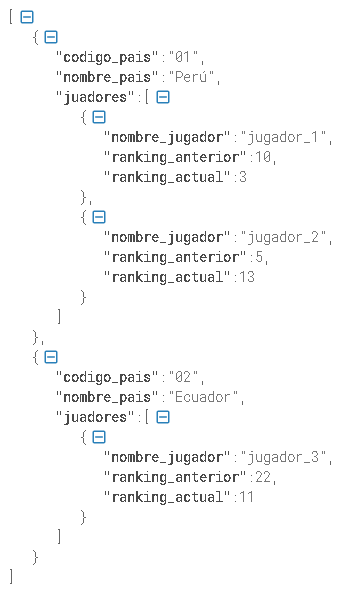

In [22]:
# Ejercicio 8 Pyspark

import sys
from pyspark.mllib.random import RandomRDDs
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
from pyspark.sql.window import Window
from pyspark.sql.functions import *

spark = SparkSession.builder\
        .master("local")\
        .appName("Colab")\
        .config('spark.ui.port', '4050')\
        .getOrCreate()

# esquema de jugador: [(ranking, nombre, codigo_pais, numero_goles, numero_partidos_jugados)]
jugador = [("1", "Cristiano Ronaldo", "32", "115", "184"),("2", "Ali Daei", "24", "109", "148"),("3", "Mokhtar Dahari", "28", "89", "142"),("4", "Ferenc Puskás", "20", "84", "89"),("5", "Lionel Messi", "5", "81", "158"),("6", "Sunil Chhetri", "21", "80", "125"),("7", "Ali Mabkhout", "13", "79", "104"),("8", "Godfrey Chitalu", "39", "79", "111"),("9", "Hussein Saeed", "23", "78", "137"),("10", "Pelé", "8", "77", "92"),("11", "Sándor Kocsis", "19", "75", "68"),("12", "Kunishige Kamamoto", "26", "75", "76"),("13", "Bashar Abdullah", "27", "75", "134"),("14", "Robert Lewandowski", "31", "74", "128"),("15", "Majed Abdullah", "4", "72", "117"),("16", "Kinnah Phiri", "29", "71", "117"),("17", "Kiatisuk Senamuang", "36", "71", "134"),("18", "Miroslav Klose", "1", "71", "137"),("19", "Piyapong Pue-on", "36", "70", "100"),("20", "Abdul Kadir", "22", "70", "111"),("21", "Stern John", "37", "70", "115"),("22", "Neymar", "8", "70", "116"),("23", "Gerd Müller", "2", "68", "62"),("24", "Romelu Lukaku", "6", "68", "101"),("25", "Carlos Ruiz Gutiérrez", "17", "68", "133"),("26", "Robbie Keane", "25", "68", "146"),("27", "Hossam Hassan", "12", "68", "176"),("28", "Luis Suárez", "38", "67", "130"),("29", "Didier Drogba", "11", "65", "105"),("30", "Jasem Al-Huwaidi", "27", "63", "83"),("31", "Ronaldo Nazario", "8", "62", "98"),("32", "Zlatan Ibrahimović", "35", "62", "120"),("33", "Ahmed Radhi", "23", "62", "121"),("34", "Abdul Ghani Minhat", "16", "61", "71"),("35", "Edin Džeko", "7", "60", "118"),("36", "Imre Schlosser", "19", "59", "68"),("37", "David Villa", "14", "59", "98"),("38", "Cha Bum-Kun", "10", "58", "135"),("39", "Ali Ashfaq", "30", "57", "89"),("40", "Carlos Pavón", "18", "57", "101"),("41", "Clint Dempsey", "15", "57", "141"),("42", "Younis Mahmoud", "23", "57", "148"),("43", "Landon Donovan", "15", "57", "157"),("44", "Samuel Eto'o", "9", "56", "118"),("45", "Romário", "8", "55", "70"),("46", "Kazuyoshi Miura", "26", "55", "89"),("47", "Jan Koller", "33", "55", "91"),("48", "Iswadi Idris", "22", "55", "97"),("49", "Fandi Ahmad", "34", "55", "101"),("50", "Joachim Streich", "3", "55", "102")]

# esquema de país: [(codigo_pais, nombre_pais)]
pais = [("1", " Alemania"),("2", " Alemania Federal"),("3", " Alemania Oriental"),("4", " Arabia Saudita"),("5", " Argentina"),("6", " Bélgica"),("7", " Bosnia y Herzegovina"),("8", " Brasil"),("9", " Camerún"),("10", " Corea del Sur"),("11", " Costa de Marfil"),("12", " Egipto"),("13", " Emiratos Arabes Unidos"),("14", " España"),("15", " Estados Unidos"),("16", " Federación Malaya/ Malasia"),("17", " Guatemala"),("18", " Honduras"),("19", " Hungría"),("20", " Hungría/ España"),("21", " India"),("22", " Indonesia"),("23", " Irak"),("24", " Irán"),("25", " Irlanda"),("26", " Japón"),("27", " Kuwait"),("28", " Malasia"),("29", " Malawi"),("30", " Maldivas"),("31", " Polonia"),("32", " Portugal"),("33", " República Checa"),("34", " Singapur"),("35", " Suecia"),("36", " Tailandia"),("37", " Trinidad y Tobago"),("38", " Uruguay"),("39", " Zambia")]

####### PROGRAME SU RESPUESTA AQUI ##############

# Respuesta 2.1
# 4.1 Crear dos dataframes en función de las listas entregadas.
# ===============================================
print('\n4.1 Crear dos dataframes en función de las listas entregadas.')

jugador_int = [
    (int(ranking), nombre, codigo_pais, int(goles), int(partidos))
    for ranking, nombre, codigo_pais, goles, partidos in jugador
]
esquema_jugador = StructType([
    StructField("ranking", IntegerType(), True),
    StructField("nombre_jugador", StringType(), True),
    StructField("codigo_pais", StringType(), True),
    StructField("numero_goles", IntegerType(), True),
    StructField("numero_partidos_jugados", IntegerType(), True)
])

df_jugador = spark.createDataFrame(jugador_int, schema=esquema_jugador)
print('\nDATAFRAME JUGADORES:')
print('\n')
df_jugador.show(5)


esquema_pais = StructType([
    StructField("codigo_pais", StringType(), True),
    StructField("nombre_pais", StringType(), True)
])

df_pais = spark.createDataFrame(pais, schema=esquema_pais)
print('\nDATAFRAME PAISES:')
print('\n')
df_pais.show(5)

# Respuesta 2.2
# ===============================================
print('\n4.2. Consolidar los datos y crear una marca que permita identificar el mejor jugador rankeado por país.')

# vamos a unir a jugadores con países
df_consolidado = df_jugador.join(df_pais, on="codigo_pais", how="inner")

print("\nDATAFRAME CONSOLIDADO (jugadores + país):")
df_consolidado.select("nombre_jugador", "nombre_pais", "numero_goles").show(5)

# defino una ventana por país, ordenada por número de goles descendente
ventana = Window.partitionBy("codigo_pais").orderBy(col("numero_goles").desc())

# aplico un ranking dentro de cada país
df_ranked = df_consolidado.withColumn("posicion_en_pais", rank().over(ventana))

# creo una marca para el mejor jugador de cada país
df_mejor_jugador = df_ranked.withColumn(
    "mejor_jugador",
    when(col("posicion_en_pais") == 1, True).otherwise(False)
)

print("\nJUGADORES CON MARCA DE MEJOR JUGADOR POR PAÍS:")
df_mejor_jugador.select(
    "nombre_pais", "nombre_jugador", "numero_goles", "posicion_en_pais", "mejor_jugador"
).show(10)


# Respuesta 2.3
# ===============================================

print("\n4.3. Proponga un nuevo ranking en base a un indicador diseñado por usted que permita considerar no solamente los goles logrados, sinó que tenga en cuenta el número de partidos que necesitó para lograr esa cantidad de goles.")

#para este punto veremos la eficiencia de los jugadores identificando cuántos goles hizo por partido

# cálculo del indicador de eficiencia goleadora
df_indicador = df_mejor_jugador.withColumn(
    "eficiencia_goles",
    round(col("numero_goles") / col("numero_partidos_jugados"), 4)
)

# creo una ventana global para generar un nuevo ranking general
ventana_global = Window.orderBy(col("eficiencia_goles").desc())

# asigno el nuevo ranking basado en la eficiencia
df_nuevo_ranking = df_indicador.withColumn(
    "ranking_nuevo",
    rank().over(ventana_global)
)

print("\nNUEVO RANKING BASADO EN EFICIENCIA GOLEADORA:")
df_nuevo_ranking.select(
    "ranking_nuevo", "nombre_jugador", "nombre_pais", "numero_goles", "numero_partidos_jugados", "eficiencia_goles"
).orderBy("ranking_nuevo").show(10)

# Respuesta 2.4
# ===============================================

#################################################

print('\n4.4 Almacenar el resultado en un archivo json ubicado en la ruta /tmp/Nuevo_Ranking.json con la siguiente estructura de')

# selecciono los campos relevantes
df_final = df_nuevo_ranking.select(
    "codigo_pais",
    "nombre_pais",
    "nombre_jugador",
    col("ranking").alias("ranking_anterior"),
    col("ranking_nuevo").alias("ranking_actual")
)

# agrupo por país y generamos una lista de jugadores
df_json = df_final.groupBy("codigo_pais", "nombre_pais").agg(
    collect_list(
        struct(
            col("nombre_jugador"),
            col("ranking_anterior"),
            col("ranking_actual")
        )
    ).alias("jugadores")
)

# Mostramos cómo queda estructurado
df_json.show(truncate=False)

# Guardamos en formato JSON
df_json.write.mode("overwrite").json("/tmp/Nuevo_Ranking.json")

print("\nArchivo JSON generado exitosamente en /tmp/Nuevo_Ranking.json")


spark.stop()


4.1 Crear dos dataframes en función de las listas entregadas.

DATAFRAME JUGADORES:


+-------+-----------------+-----------+------------+-----------------------+
|ranking|   nombre_jugador|codigo_pais|numero_goles|numero_partidos_jugados|
+-------+-----------------+-----------+------------+-----------------------+
|      1|Cristiano Ronaldo|         32|         115|                    184|
|      2|         Ali Daei|         24|         109|                    148|
|      3|   Mokhtar Dahari|         28|          89|                    142|
|      4|    Ferenc Puskás|         20|          84|                     89|
|      5|     Lionel Messi|          5|          81|                    158|
+-------+-----------------+-----------+------------+-----------------------+
only showing top 5 rows


DATAFRAME PAISES:


+-----------+------------------+
|codigo_pais|       nombre_pais|
+-----------+------------------+
|          1|          Alemania|
|          2|  Alemania Federal|
|        

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
!ls -l /tmp/Nuevo_Ranking.json

total 8
-rw-r--r-- 1 root root 6338 Nov  1 16:58 part-00000-6872c7c8-82c2-4733-b4cc-50b8da81b67b-c000.json
-rw-r--r-- 1 root root    0 Nov  1 16:58 _SUCCESS


####PySpark: Pregunta 5:  Subir el archivo CENTROS_EDUCACION_MADRID.json a la ruta /content
<b> 5.1 Preparar un programa de pyspark que permita leer el archivo "CENTROS_EDUCACION_MADRID.json".

<b> 5.2 Periódicamente se realizarán reuniones de todos los centros que pertenezcan a un mismo "centro_titularidad" y se necesita determinar qué Centro educativo es el mas céntrico.   Para esto se cuenta con las coordenadas de cada centro educativo ("direccion_coor_x" y "direccion_coor_y").   

Procedimiento sugerido:  
   5.2.1  Determinar el promedio de las coordenadas "x" y "y" por cada grupo "centro_titularidad".

   5.2.2  Crear una udf que permita calcular la distancia euclideana desde cada unidad educativa del grupo hacia este punto promedio.

   5.2.3  Identificar cuál es la unidad educativa con menor distancia dentro de cada grupo.  Esta será la elegida como centro de reunión.

* DISTANCIA EUCLIDIANA
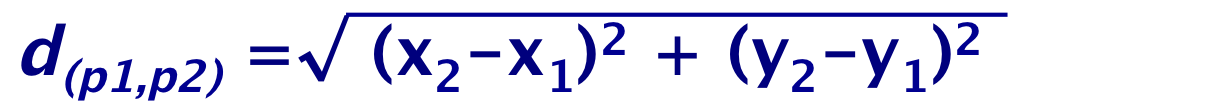


In [33]:
from typing import cast
import sys
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import explode, col, desc, avg, min, max, rank, asc, round
from pyspark.sql import Window
from math import sqrt
from pyspark.sql.functions import udf

spark = SparkSession.builder\
        .master("local")\
        .appName("Colab")\
        .config('spark.ui.port', '4050')\
        .getOrCreate()

####### PROGRAME SU RESPUESTA AQUI ##############

# 5.1 Leer el archivo JSON

df = spark.read.option("multiLine", True).json("/content/CENTROS_EDUCATIVOS_MADRID.json")
print("=== Vista previa del archivo ===")
df.show(5, truncate=False)
df.printSchema()

# 5.2 Filtrar filas con coordenadas válidas
df_validos = df.filter(col("direccion_coor_x").isNotNull() & col("direccion_coor_y").isNotNull())

# 5.2.1 Calcular promedio de coordenadas por centro_titularidad
df_promedios = df_validos.groupBy("centro_titularidad")\
                         .agg(avg("direccion_coor_x").alias("prom_x"),
                              avg("direccion_coor_y").alias("prom_y"))

####### 5.2 Calcular centro más céntrico por centro_titularidad

# 5.2.2 Crear UDF para distancia euclideana segura
def distancia(x, y, prom_x, prom_y):
    if x is None or y is None or prom_x is None or prom_y is None:
        return None
    return sqrt((x - prom_x)**2 + (y - prom_y)**2)

distancia_udf = udf(distancia, DoubleType())

# Unir promedio con los centros válidos
df_union = df_validos.join(df_promedios, on="centro_titularidad", how="left")

# Calcular distancia de cada centro al promedio de su grupo
df_union = df_union.withColumn("distancia", distancia_udf(col("direccion_coor_x"),
                                                         col("direccion_coor_y"),
                                                         col("prom_x"),
                                                         col("prom_y")))

# 5.2.3 Identificar el centro más céntrico por grupo
window = Window.partitionBy("centro_titularidad").orderBy(col("distancia").asc())
df_centro = df_union.withColumn("rank", rank().over(window))\
                    .filter(col("rank") == 1)\
                    .drop("rank", "prom_x", "prom_y")

print("=== Centros más céntricos por titularidad ===")
df_centro.select("centro_titularidad", "centro_nombre", "direccion_coor_x", "direccion_coor_y", "distancia")\
         .show(truncate=False)

#################################################


=== Vista previa del archivo ===
+-------------+------------------+------------------+--------------------------+----------------------------------------------------+-------------------+------------------+-------------------------------------------+------------+------------------+------------------+------------------+------------------+------------------------------------------------------+----------+-----------+-----------------------+----------------+----------------+----------------+---------------------+------------------+---------------+---------------+----------------+-----------------+
|centro_codigo|centro_nombre     |centro_tipo_codigo|centro_tipo_desc_abreviada|centro_tipo_descripcion                             |centro_titular     |centro_titularidad|contacto_email1                            |contacto_fax|contacto_telefono1|contacto_telefono2|contacto_telefono3|contacto_telefono4|contacto_web                                          |dat_codigo|dat_nombre |direccion_codigo_

<b> 5.3 Exportar el resultado del ejercicio anterior en tres formatos:
1. parquet
2. json
3. csv (separado por caracter '|' y conservando la cabecera de la data)

Los tres archivos deberán crearse en la ruta /tmp

5.4.  Qué formato utilizaría para almacenar y procesar grandes volúmenes de datos en Databricks.  Justifique porqué no seleccionó los otros dos formatos.

<b>Nota:  Desarrolle su análisis en el espacio comentado


In [34]:
from typing import cast
import sys
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import explode, col, desc, avg, min, max, rank, asc, round
from pyspark.sql import Window
from math import sqrt
from pyspark.sql.functions import udf

spark = SparkSession.builder\
        .master("local")\
        .appName("Colab")\
        .config('spark.ui.port', '4050')\
        .getOrCreate()

####### PROGRAME SU RESPUESTA AQUI ##############

# Definir ruta base para exportación
ruta_base = "/tmp/centros_mas_centricos"

# 5.3 Respuesta:
# ===============================================
# Formato Parquet
df_centro.write.mode("overwrite").parquet(ruta_base + ".parquet")

# Formato JSON
df_centro.write.mode("overwrite").json(ruta_base + ".json")

# Formato CSV con '|' como separador y cabecera
df_centro.write.mode("overwrite")\
        .option("header", True)\
        .option("delimiter", "|")\
        .csv(ruta_base + ".csv")

print("=== Archivos exportados correctamente en /tmp ===")

# 5.3 Justificación:
# ===============================================
# Formato recomendado: PARQUET
# - Parquet es columnar, permite leer solo las columnas necesarias.
# - Comprime los datos eficientemente, ahorrando espacio.
# - Optimizado para procesamiento distribuido en Spark/Databricks.
# - Permite esquemas evolutivos y manejo de grandes volúmenes sin perder performance.
#
# Razones para no elegir los otros:
# - JSON: Legible, pero texto plano, mayor tamaño y tiempo de lectura/escritura.
# - CSV: Texto plano, sin tipado, requiere parseo adicional, menos eficiente para análisis distribuido.

#################################################


=== Archivos exportados correctamente en /tmp ===
